In [1]:
# Async send-on delta modulation

In [2]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

In [5]:
path = "../ATMEGA-AES-ASCAD_databases/ASCAD.h5" 
bd = h5.File(path, "r")

print(list(bd.keys()))

print("Keys in Profiling_traces and Attack_traces:\n")

print(list(bd["Profiling_traces"].keys()))
print(list(bd["Attack_traces"].keys()))

print("\nProfiling_traces shapes:")

print(list(bd["Profiling_traces"]["traces"].shape))
print(list(bd["Profiling_traces"]["labels"].shape))
print(list(bd["Profiling_traces"]["metadata"].shape))

print("\nAttack_traces shapes:")

print(list(bd["Attack_traces"]["traces"].shape))
print(list(bd["Attack_traces"]["labels"].shape))
print(list(bd["Attack_traces"]["metadata"].shape))

['Attack_traces', 'Profiling_traces']
Keys in Profiling_traces and Attack_traces:

['labels', 'metadata', 'traces']
['labels', 'metadata', 'traces']

Profiling_traces shapes:
[50000, 700]
[50000]
[50000]

Attack_traces shapes:
[10000, 700]
[10000]
[10000]


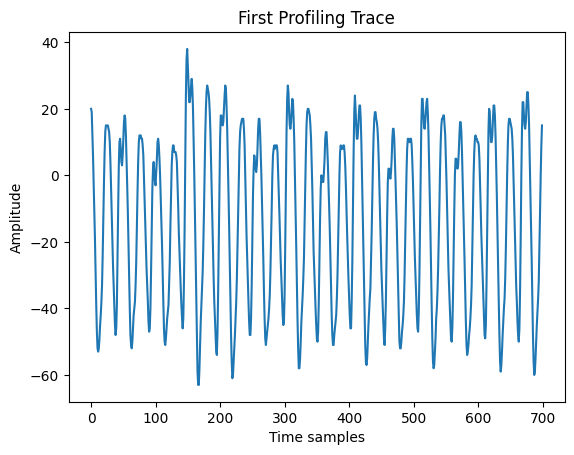

In [4]:
plt.plot(bd["Profiling_traces"]["traces"][0])
plt.title("First Profiling Trace")
plt.xlabel("Time samples")
plt.ylabel("Amplitude")
plt.show() 

In [5]:
import numpy as np

amostras = bd["Profiling_traces"]["traces"][:50000]

# int8 to int32 to avoid overflow
amostras_int32 = np.array(amostras, dtype=np.int32)

# derivative across time samples
derivadas = np.diff(amostras_int32, axis=1)

# convert all to absolute value
derivadas_absolutas = np.abs(derivadas)

# mean across all 10,000 traces and round to integer threshold
threshold_ideal = int(np.round(np.mean(derivadas_absolutas)))

print(f"Statistically calculated ideal threshold: {threshold_ideal}")

Statistically calculated ideal threshold: 6


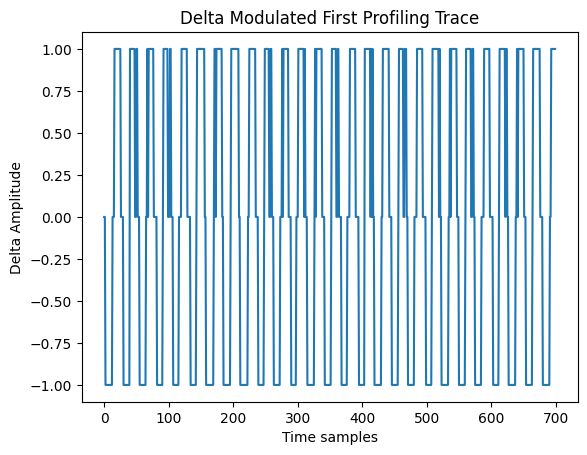

In [6]:
import delta_mod

threshold = threshold_ideal
delta_traces = [list(delta_mod.delta_modulation(trace, threshold)) for trace in bd["Profiling_traces"]["traces"]]

plt.plot(delta_traces[0])
plt.title("Delta Modulated First Profiling Trace")
plt.xlabel("Time samples")
plt.ylabel("Delta Amplitude")
plt.show()

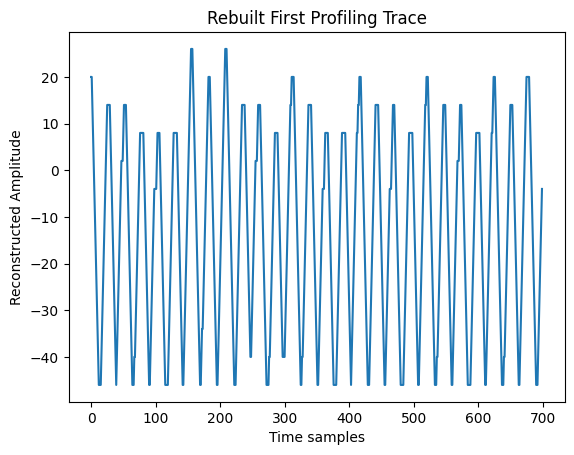

In [7]:
rebuilt_traces = [list(delta_mod.rebuild_trace(delta_trace, bd["Profiling_traces"]["traces"][i][0], threshold)) for i, delta_trace in enumerate(delta_traces)]

plt.plot(rebuilt_traces[0])
plt.title("Rebuilt First Profiling Trace")
plt.xlabel("Time samples")
plt.ylabel("Reconstructed Amplitude")
plt.show()

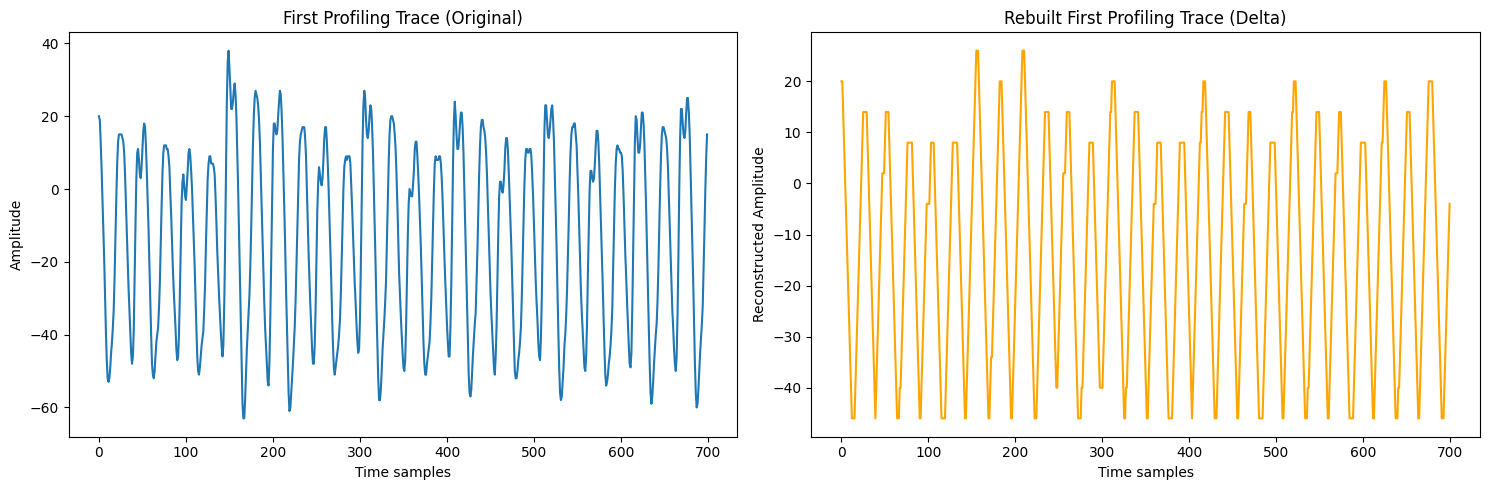

In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(bd["Profiling_traces"]["traces"][0])
ax1.set_title("First Profiling Trace (Original)")
ax1.set_xlabel("Time samples")
ax1.set_ylabel("Amplitude")

ax2.plot(rebuilt_traces[0], color='orange')
ax2.set_title("Rebuilt First Profiling Trace (Delta)")
ax2.set_xlabel("Time samples")
ax2.set_ylabel("Reconstructed Amplitude")

plt.tight_layout()
plt.show()

In [9]:
import time
import os
import re
import subprocess

trace0 = bd["Profiling_traces"]["traces"][0]

start = time.perf_counter()
_ = list(delta_mod.delta_modulation(trace0, threshold))
end = time.perf_counter()
python_time = end - start

c_time = "unavailable"
c_time_float = None

if os.path.exists("./benchmark_conversion"):
    result = subprocess.run(["./benchmark_conversion"], capture_output=True, text=True, check=False)
    match = re.search(r"([0-9]+\.[0-9]+) s", result.stdout)
    if match:
        c_time_float = float(match.group(1))
        c_time = f"{c_time_float:.9f} s"

speedup = "unavailable"
if c_time_float is not None and c_time_float > 0:
    faster_percent = ((python_time - c_time_float) / python_time) * 100
    speedup = f"{faster_percent:.2f}% faster"

print("timing comparison for delta modulation of a single trace")
print(f"time for deltamod Python: {python_time:.9f} s")
print(f"time for deltamod C: {c_time}")
print(f"C implementation is: {speedup}")

timing comparison for delta modulation of a single trace
time for deltamod Python: 0.000588419 s
time for deltamod C: 0.000008000 s
C implementation is: 98.64% faster


## Post Delta Mod H5 db

In [10]:
path = "../ATMEGA-AES-ASCAD_databases/ascad_modulated.h5" 
bd = h5.File(path, "r")

print(list(bd.keys()))

print("Keys in Profiling_traces and Attack_traces:\n")

print(list(bd["Profiling_traces"].keys()))
print(list(bd["Attack_traces"].keys()))

print("\nProfiling_traces shapes:")

print(list(bd["Profiling_traces"]["traces"].shape))
print(list(bd["Profiling_traces"]["labels"].shape))
print(list(bd["Profiling_traces"]["metadata"].shape))

print("\nAttack_traces shapes:")

print(list(bd["Attack_traces"]["traces"].shape))
print(list(bd["Attack_traces"]["labels"].shape))
print(list(bd["Attack_traces"]["metadata"].shape))

['Attack_traces', 'Profiling_traces']
Keys in Profiling_traces and Attack_traces:

['labels', 'metadata', 'traces']
['labels', 'metadata', 'traces']

Profiling_traces shapes:
[50000, 700]
[50000]
[50000]

Attack_traces shapes:
[10000, 700]
[10000]
[10000]


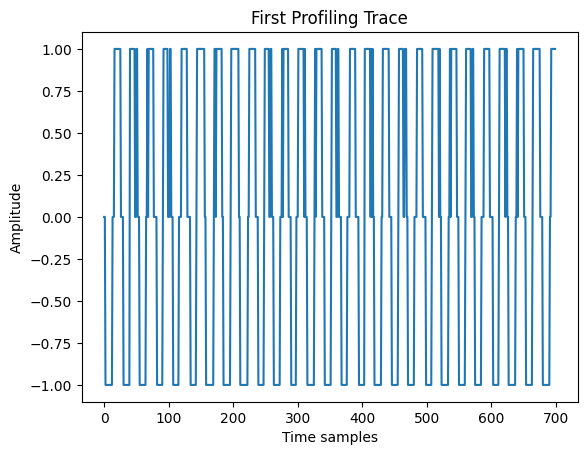

In [11]:
plt.plot(bd["Profiling_traces"]["traces"][0])
plt.title("First Profiling Trace")
plt.xlabel("Time samples")
plt.ylabel("Amplitude")
plt.show()

## Hamming Weights

In [12]:
AES_SBOX = [
    0x63, 0x7c, 0x77, 0x7b, 0xf2, 0x6b, 0x6f, 0xc5,
    0x30, 0x01, 0x67, 0x2b, 0xfe, 0xd7, 0xab, 0x76,

    0xca, 0x82, 0xc9, 0x7d, 0xfa, 0x59, 0x47, 0xf0,
    0xad, 0xd4, 0xa2, 0xaf, 0x9c, 0xa4, 0x72, 0xc0,

    0xb7, 0xfd, 0x93, 0x26, 0x36, 0x3f, 0xf7, 0xcc,
    0x34, 0xa5, 0xe5, 0xf1, 0x71, 0xd8, 0x31, 0x15,

    0x04, 0xc7, 0x23, 0xc3, 0x18, 0x96, 0x05, 0x9a,
    0x07, 0x12, 0x80, 0xe2, 0xeb, 0x27, 0xb2, 0x75,

    0x09, 0x83, 0x2c, 0x1a, 0x1b, 0x6e, 0x5a, 0xa0,
    0x52, 0x3b, 0xd6, 0xb3, 0x29, 0xe3, 0x2f, 0x84,

    0x53, 0xd1, 0x00, 0xed, 0x20, 0xfc, 0xb1, 0x5b,
    0x6a, 0xcb, 0xbe, 0x39, 0x4a, 0x4c, 0x58, 0xcf,

    0xd0, 0xef, 0xaa, 0xfb, 0x43, 0x4d, 0x33, 0x85,
    0x45, 0xf9, 0x02, 0x7f, 0x50, 0x3c, 0x9f, 0xa8,

    0x51, 0xa3, 0x40, 0x8f, 0x92, 0x9d, 0x38, 0xf5,
    0xbc, 0xb6, 0xda, 0x21, 0x10, 0xff, 0xf3, 0xd2,

    0xcd, 0x0c, 0x13, 0xec, 0x5f, 0x97, 0x44, 0x17,
    0xc4, 0xa7, 0x7e, 0x3d, 0x64, 0x5d, 0x19, 0x73,

    0x60, 0x81, 0x4f, 0xdc, 0x22, 0x2a, 0x90, 0x88,
    0x46, 0xee, 0xb8, 0x14, 0xde, 0x5e, 0x0b, 0xdb,

    0xe0, 0x32, 0x3a, 0x0a, 0x49, 0x06, 0x24, 0x5c,
    0xc2, 0xd3, 0xac, 0x62, 0x91, 0x95, 0xe4, 0x79,

    0xe7, 0xc8, 0x37, 0x6d, 0x8d, 0xd5, 0x4e, 0xa9,
    0x6c, 0x56, 0xf4, 0xea, 0x65, 0x7a, 0xae, 0x08,

    0xba, 0x78, 0x25, 0x2e, 0x1c, 0xa6, 0xb4, 0xc6,
    0xe8, 0xdd, 0x74, 0x1f, 0x4b, 0xbd, 0x8b, 0x8a,

    0x70, 0x3e, 0xb5, 0x66, 0x48, 0x03, 0xf6, 0x0e,
    0x61, 0x35, 0x57, 0xb9, 0x86, 0xc1, 0x1d, 0x9e,

    0xe1, 0xf8, 0x98, 0x11, 0x69, 0xd9, 0x8e, 0x94,
    0x9b, 0x1e, 0x87, 0xe9, 0xce, 0x55, 0x28, 0xdf,

    0x8c, 0xa1, 0x89, 0x0d, 0xbf, 0xe6, 0x42, 0x68,
    0x41, 0x99, 0x2d, 0x0f, 0xb0, 0x54, 0xbb, 0x16
]

In [ ]:
metadata = bd["Profiling_traces"]["metadata"]
print("metadata type:", type(metadata))
print("metadata shape:", metadata.shape)
print("metadata dtype:", metadata.dtype)
print("metadata dtype names:", metadata.dtype.names)
print("\nFirst rows:")
print(metadata[:3])
#('plaintext', 'ciphertext', 'key', 'masks', 'desync')

metadata_plaintext = metadata["plaintext"]
metadata_ciphertext = metadata["ciphertext"]
metadata_key = metadata["key"]
metadata_masks = metadata["masks"]
metadata_desync = metadata["desync"]